In [1]:
import pandas as pd
import numpy as np # Biblioteca necessária para manipulações numéricas e de estruturas de dados contínuas.
import matplotlib.pyplot as plt # Visualizações dos gráficos.
from bess_api import BESS # Nossa DLL encapsulada em uma classe Python chamada BESS.


In [2]:
def plot_power_curve(curve, title="POTÊNCIA - P (kW)"):
    hours = np.arange(1, len(curve) + 1)

    plt.figure(figsize=(10, 5))

    # Linha principal
    plt.plot(hours, curve)

    plt.fill_between(hours, curve, 0, alpha=0.3)

    plt.axhline(0, linewidth=1)

    plt.xlim(1, 24)
    plt.xticks(range(1, 25))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.title(title, fontsize=12, fontweight='bold')

    plt.xlabel("Hora")
    plt.ylabel("Potência (kW)")

    plt.tight_layout()
    plt.show()


# Análise da classe BESS

## Testando as funcionalidades da biblioteca

A classe BESS presente em bess-api/ permite criar uma instância do objeto BESS, o qual possui os métodos: 

- set_curve(curve): define a curva inicial a user utilizada pelo objeto; 
- daily_energy: retorna a potência diária armazenada;
- monthly_energy: retorna a potência mensal armazenada;
- result_at(t): retorna o ponto da curva resultante no instante t;
- set_dispatch(start, end): define o intervalo de despacho com um horário de início e de término passados como parâmetros;
- run_dispatch(): realiza o "despacho" da bateria no intervalo de despacho previamente definido;
- result_curve: retorna uma lista contendo a curva resultante após a simulação do despacho.

In [3]:
# Curva inicial fornecida na Tabela 1 do teste. 
curve = np.array([
    1.96887689, 1.140204703, 1.017916887, 0.93782698,
    0.957849457, 0.0, -0.397693755, -1.759566653,
    -3.440076817, -3.815379846, -4.316415417, -4.146073657,
    -3.95334117, -3.074246789, -1.756810872, -0.007061691,
    2.199027726, 3.122645206, 4.246272159, 4.869552487,
    4.161015161, 3.485633335, 2.328850882, 2.748461714
], dtype=np.float64)

In [4]:
bess = BESS()

# Set da curva inicial.
bess.set_curve(curve)

# Potências diárias e mensais armazenadas
print(f"Potência diária armazenada: {bess.daily_energy:.3f} kWh.")
print(f"Potência mensal armazenada: {bess.monthly_energy:.3f} kWh.")

# Set do intervalo de despacho como sendo das 17h às 05h.
bess.set_dispatch(17, 5)

# Simulação do despacho da bateria. 
bess.run_dispatch()

print()
# Pontos da curva em um instante t.
print("Exibindo pontos da curva resultante a partir de um instante:")
print(f"20h: {bess.result_at(20):.3f}.")
print(f"11h: {bess.result_at(11):.3f}.")
print(f"16h: {bess.result_at(16):.3f}.")

Potência diária armazenada: 26.667 kWh.
Potência mensal armazenada: 800.000 kWh.

Exibindo pontos da curva resultante a partir de um instante:
20h: 0.956.
11h: -4.316.
16h: -0.007.


**Curva Original**

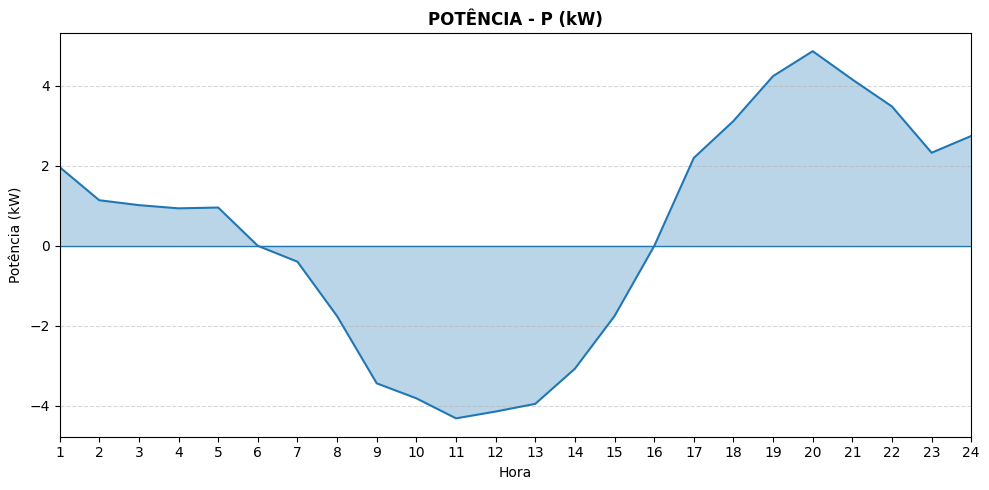

In [13]:
plot_power_curve(curve)

**Curva resultante**

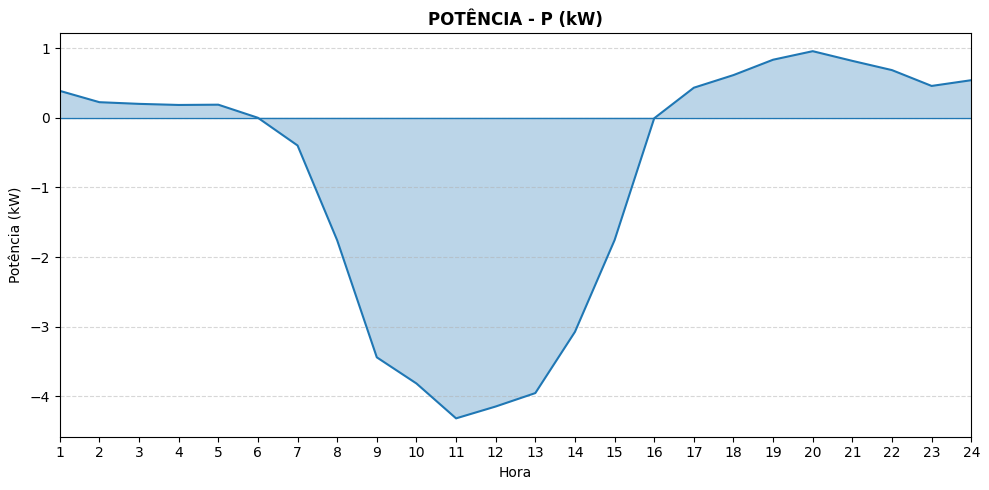

In [15]:
plot_power_curve(bess.result_curve)

## Tratamento de erros 

A biblioteca possui tratamento de erros com a conversão de exceções lançadas pelo C++ em RunTimeErros do Python. 

**Alguns exemplos de erros**

In [5]:
bess2 = BESS()

bess.set_dispatch(17, 25) # Intervalo fora do esperado. 

RuntimeError: As horas do intervalo de despacho devem estar entre 1 e 24.

In [7]:
# Como não definimos a curva original, então haverão erros nos demais métodos. 

bess2.daily_energy

RuntimeError: Curva não definida.

In [10]:
# Mais um exemplo. 

bess2.run_dispatch()

RuntimeError: Curva não definida.

# Conclusões

- A classe solicitada foi implementada e compilada em C++;
- Foi utilizada a biblioteca ctypes para conversão ler a DLL no Python; 
- Utilizado o conceito de classe "wrapper" para encapsular as chamadas mais "baixo-nível" da DLL e tornar a utilização pelo usuário mais intuitiva e simples;
- Tratamento de erros com capturas de exceções C++ e conversão em RunTimeErrors do Python; 
- Todas os métodos e funcionalidades solicitadas estão funcionais.